In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [3]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

db = client["chatbot_db"]
collection = db["chat_memory"]

In [4]:
# Save Chat

from datetime import datetime

def save_message(thread_id: str, role: str, content: str):
    collection.update_one(
        {"thread_id": thread_id},
        {
            "$push": {
                "messages": {
                    "role": role,
                    "content": content,
                    "timestamp": datetime.utcnow()
                }
            }
        },
        upsert=True
    )

In [5]:
# load chat

def load_messages(thread_id: str):
    chat = collection.find_one({"thread_id": thread_id})

    if not chat:
        return []

    messages = []

    for msg in chat["messages"]:
        if msg["role"] == "user":
            messages.append(HumanMessage(content=msg["content"]))
        else:
            messages.append(AIMessage(content=msg["content"]))

    return messages

In [6]:
llm = ChatOpenAI(model="gpt-5-nano")

In [7]:
class Msgstate(TypedDict):

    messages : Annotated[list, add_messages]

In [1]:
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [16]:
def llm_chat(state: Msgstate) -> Msgstate:

    messages = trim_messages(
        state['messages'],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=50
    )

    print("current token count -> ", count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    result = llm.invoke(messages)

    return {"messages" : result}

In [17]:
graph = StateGraph(Msgstate)

graph.add_node("llm_chat",llm_chat)

graph.add_edge(START,"llm_chat")
graph.add_edge("llm_chat", END)

workflow = graph.compile()

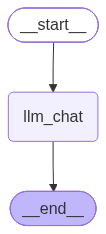

In [9]:
workflow

In [23]:
user_message = input("Enter the query here :: ")

In [24]:
thread_id = "user_456"

history = load_messages(thread_id)

history.append(HumanMessage(content=user_message))


In [25]:
final_result = workflow.invoke({"messages" : history})

answer = final_result["messages"][-1].content

current token count ->  29
what is 2+2 give in just one line
4
do you remember my name?


In [26]:
save_message(thread_id, "user", user_message)
save_message(thread_id, "assistant", answer)

C:\Users\rudra\AppData\Local\Temp\ipykernel_12956\3892126589.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow()


In [27]:
for message in final_result["messages"]:
    print(message.content)

hi, i am rudra and i am 3rd year student of computer engineering in ssasit collage. reply only in 2-3 lines
Hi Rudra! Nice to meet you, and congrats on reaching your 3rd year in computer engineering at SSASIT College.
How can I help you today?
hi, i am rudra and i am 3rd year student of computer engineering in ssasit collage. reply only in 2-3 lines
Hi Rudra! Nice to meet you, and congrats on reaching your 3rd year in computer engineering at SSASIT College.
How can I help you today?
what is 2+2 give in just one line
4
do you remember my name?
I don’t know your name—you haven’t told me. If you share it, I can use it in this chat. (I don’t retain personal details across chats unless the platform enables memory.)
